# Rotating maps

By default a PolarToolkit map is drawn with the projection's own orientation, which
puts the maximum northing at the top of the page. Many features don't sit neatly along
that axis, so the `rotation` parameter lets you turn the map to suit what you're
showing, aligning a glacier's flow axis, a rift, or a flight line with the page.

`rotation` is in **degrees clockwise**, and is available on `plot_grid()`, `basemap()`
and the `Figure` class. It is only supported for the polar stereographic projections,
EPSG:3031 and EPSG:3413.

In [11]:
%load_ext autoreload
%autoreload 2

import os

# every example here is Antarctic, so set the hemisphere once instead of passing it
os.environ["POLARTOOLKIT_HEMISPHERE"] = "south"

import pandas as pd

import polartoolkit as ptk

## Rotating an EPSG region

To demonstrate this, we use Getz Ice Shelf, which is a long, roughly rectangular ice shelf along the Amundsen Sea coast, but it runs on a diagonal in EPSG:3031, so a default map wastes a lot of space and the shelf never lines up with the frame.

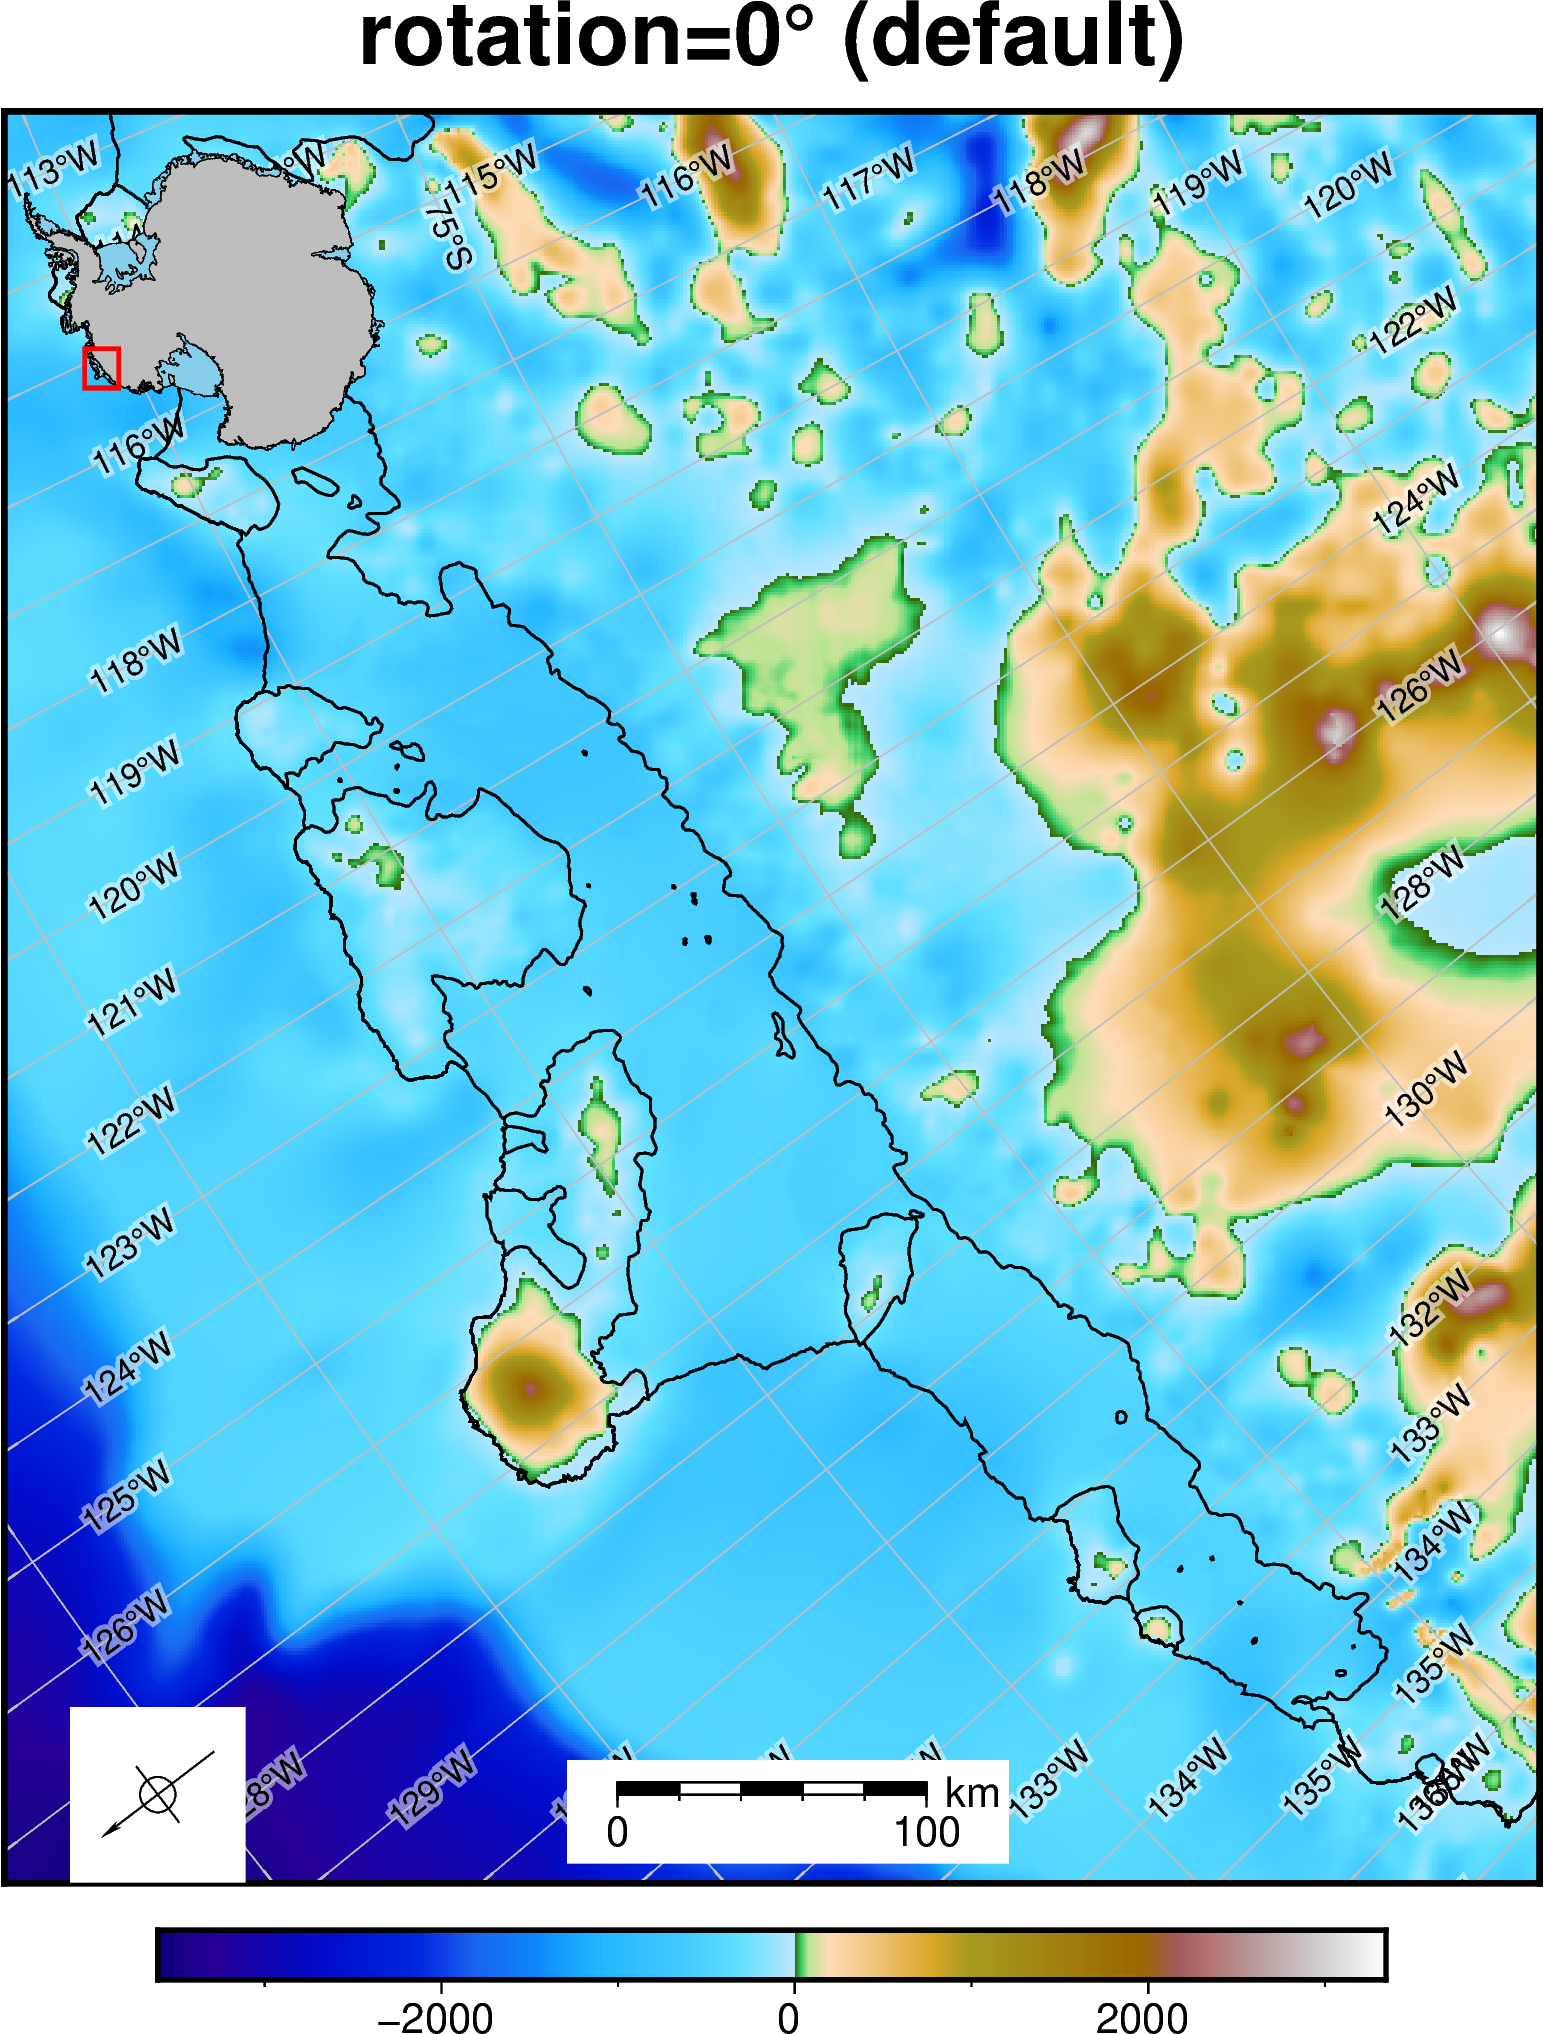

In [12]:
region = ptk.regions.getz_ice_shelf

grid = ptk.fetch.bedmap2(layer="bed", region=region)

fig = ptk.plot_grid(
    grid,
    cmap="etopo1",
    coast=True,
    gridlines=True,
    scalebar=True,
    inset=True,
    north_arrow=True,
    rose_box="+gwhite",
    rose_size="1.2c",
    title="rotation=0° (default)",
)
fig.show()

### Turning the map

Rotating clockwise by 50° stands the shelf upright, so its long axis runs down the
page. Everything turns together: the grid, the coastline, the lat/lon graticule, the
scalebar and the north arrow.

Note the north arrow still points at *true* north, so on a rotated map it no longer
points up the page.

Note too that the map has grown. The plotted region is expanded to the bounding box of
the rotated region, so nothing is cut off, but the grid we fetched
doesn't reach that far, hence the blank corners. We'll fix those next.

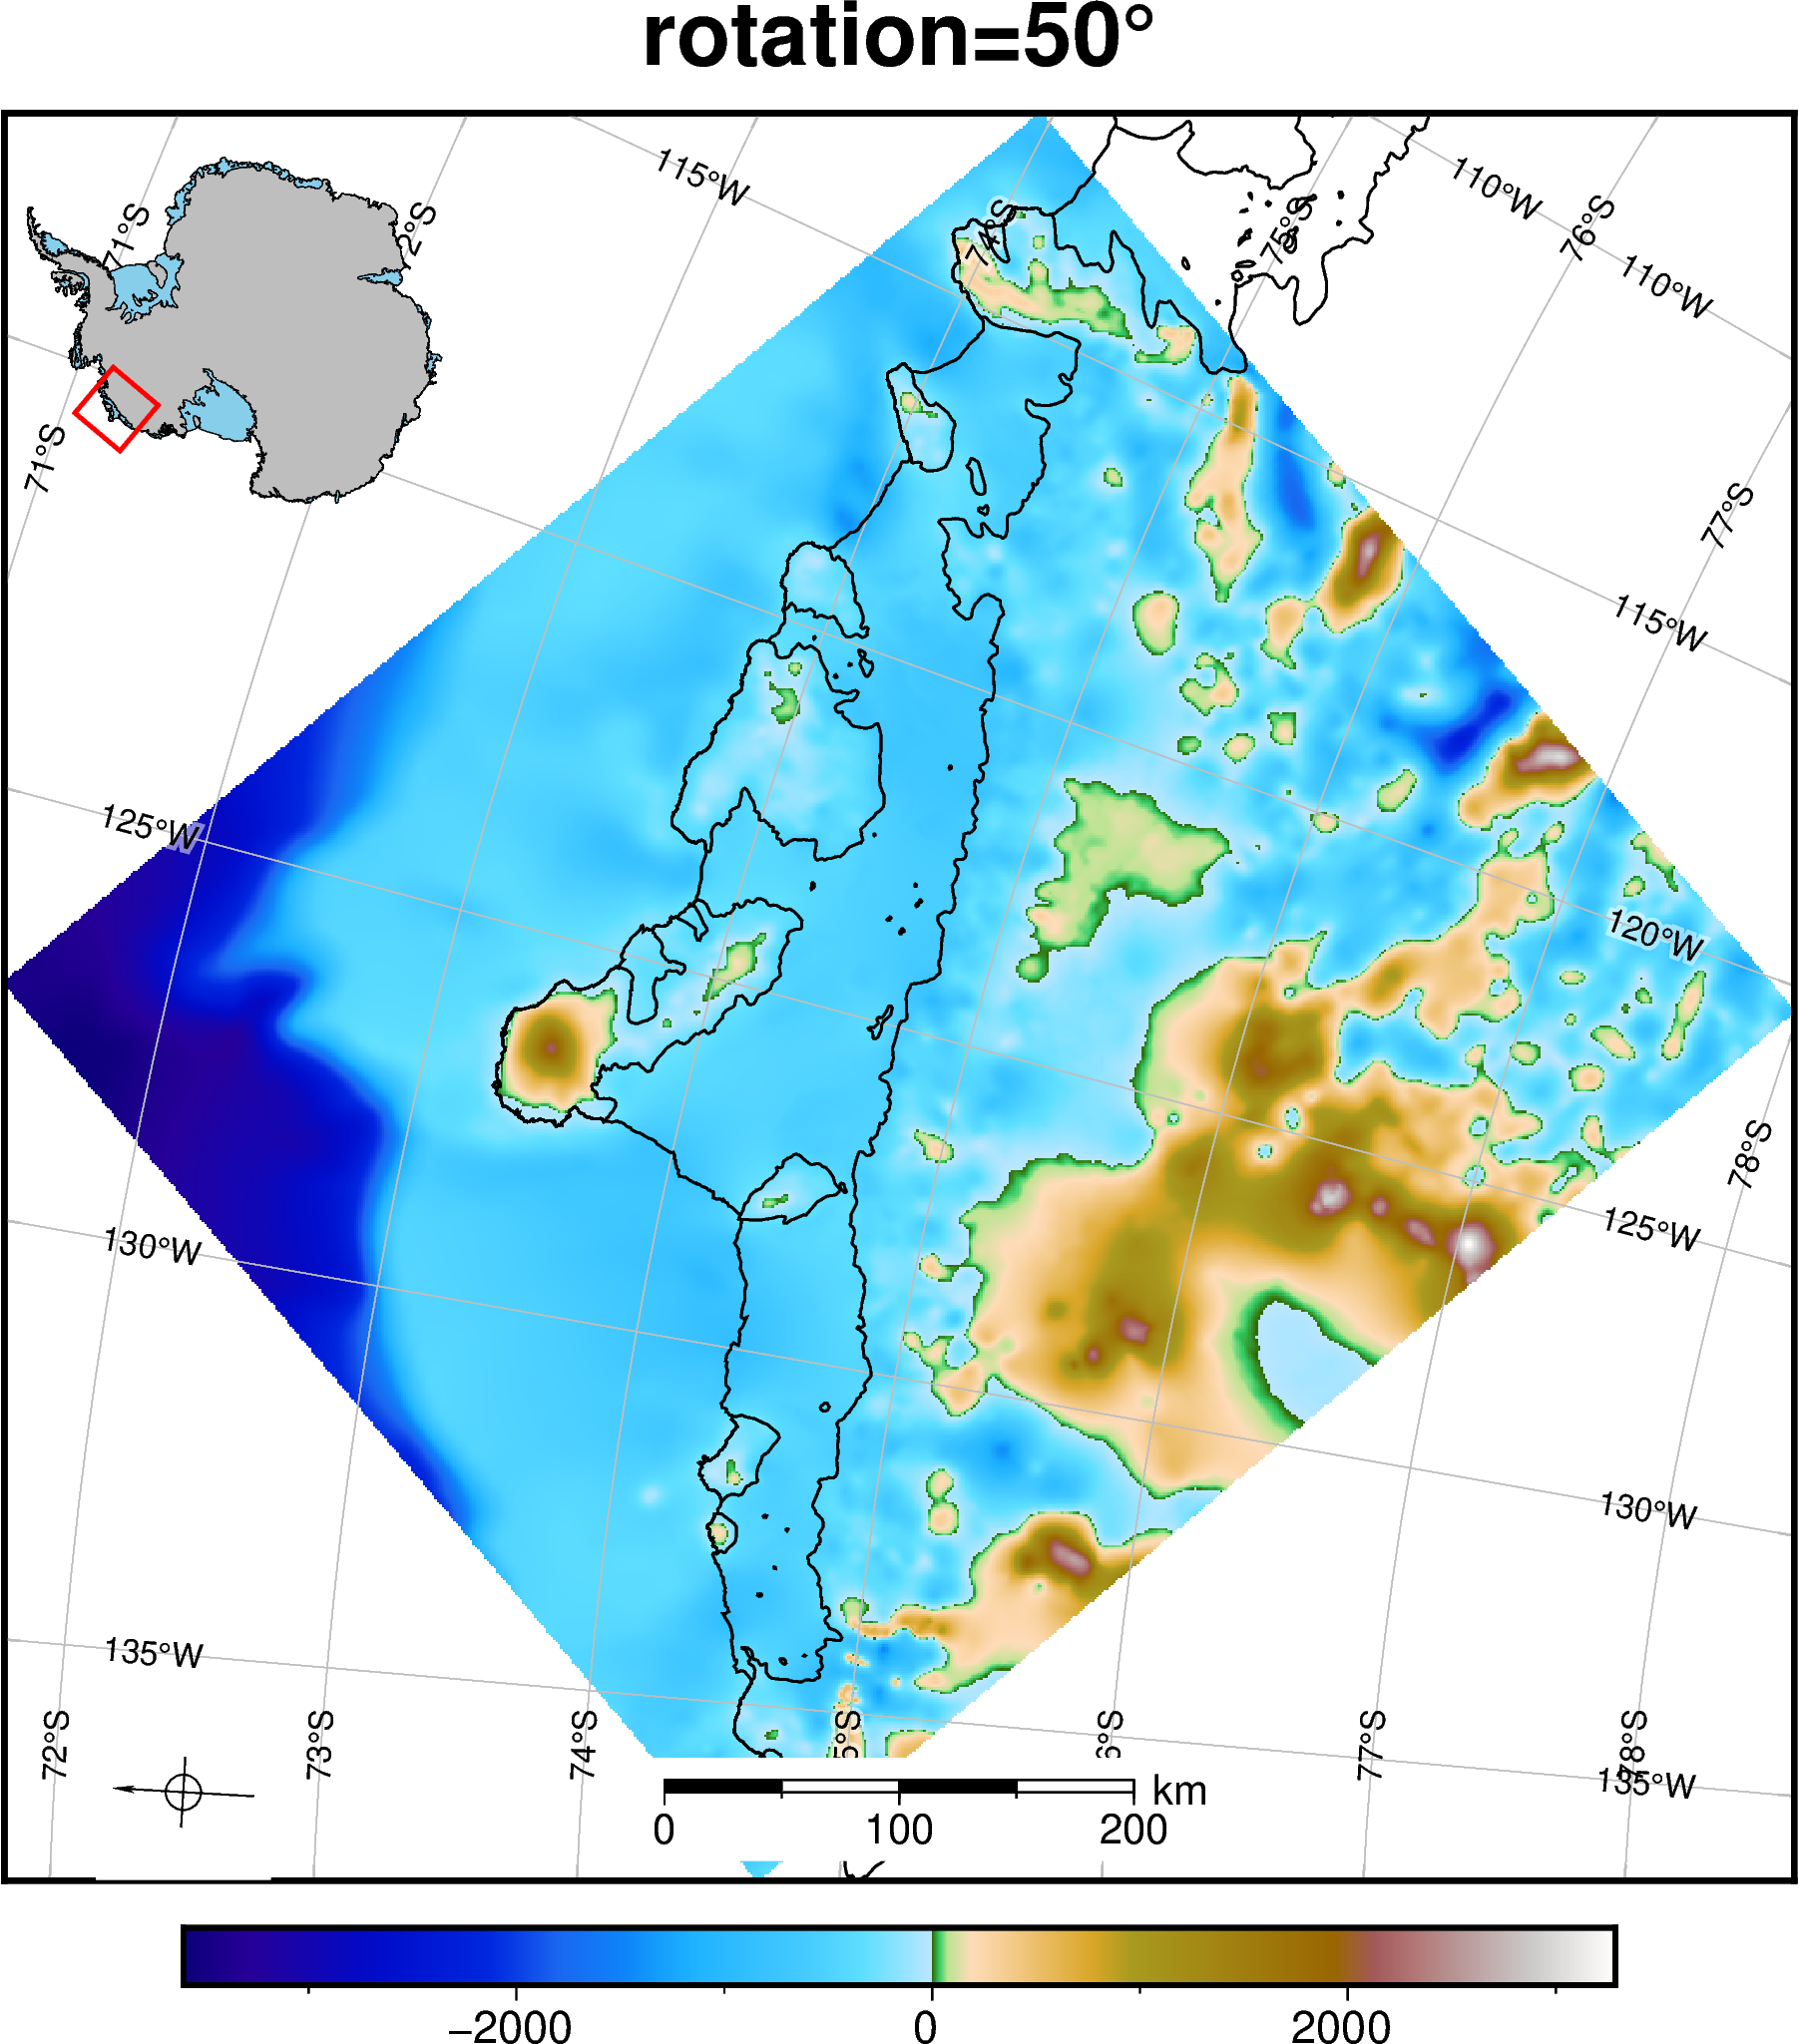

In [13]:
fig = ptk.plot_grid(
    grid,
    cmap="etopo1",
    coast=True,
    gridlines=True,
    scalebar=True,
    inset=True,
    north_arrow=True,
    rose_box="+gwhite",
    rose_size="1.2c",
    rotation=50,
    title="rotation=50°",
)
fig.show()

### Fetching data that covers the whole map

Rotating turns the map about the centre of your region, so its footprint is a
**tilted** rectangle in the original projection. A grid fetched for `region` doesn't
reach into the corners of that footprint, which is why they came out blank above.

`unrotated_region()` gives you the axis-aligned region, in unrotated coordinates, that
fully contains the rotated map. Fetch with that and the whole map is covered.

In [14]:
needed = ptk.unrotated_region(region, 50)

print(f"requested region : {tuple(round(v / 1e3) for v in region)} km")
print(f"data needed      : {tuple(round(v / 1e3) for v in needed)} km")
print()
print(
    f"requested extent : {(region[1] - region[0]) / 1e3:.0f} x {(region[3] - region[2]) / 1e3:.0f} km"
)
print(
    f"needed extent    : {(needed[1] - needed[0]) / 1e3:.0f} x {(needed[3] - needed[2]) / 1e3:.0f} km"
)

requested region : (-1624, -1130, -1234, -664) km
data needed      : (-1905, -849, -1477, -421) km

requested extent : 494 x 570 km
needed extent    : 1055 x 1056 km


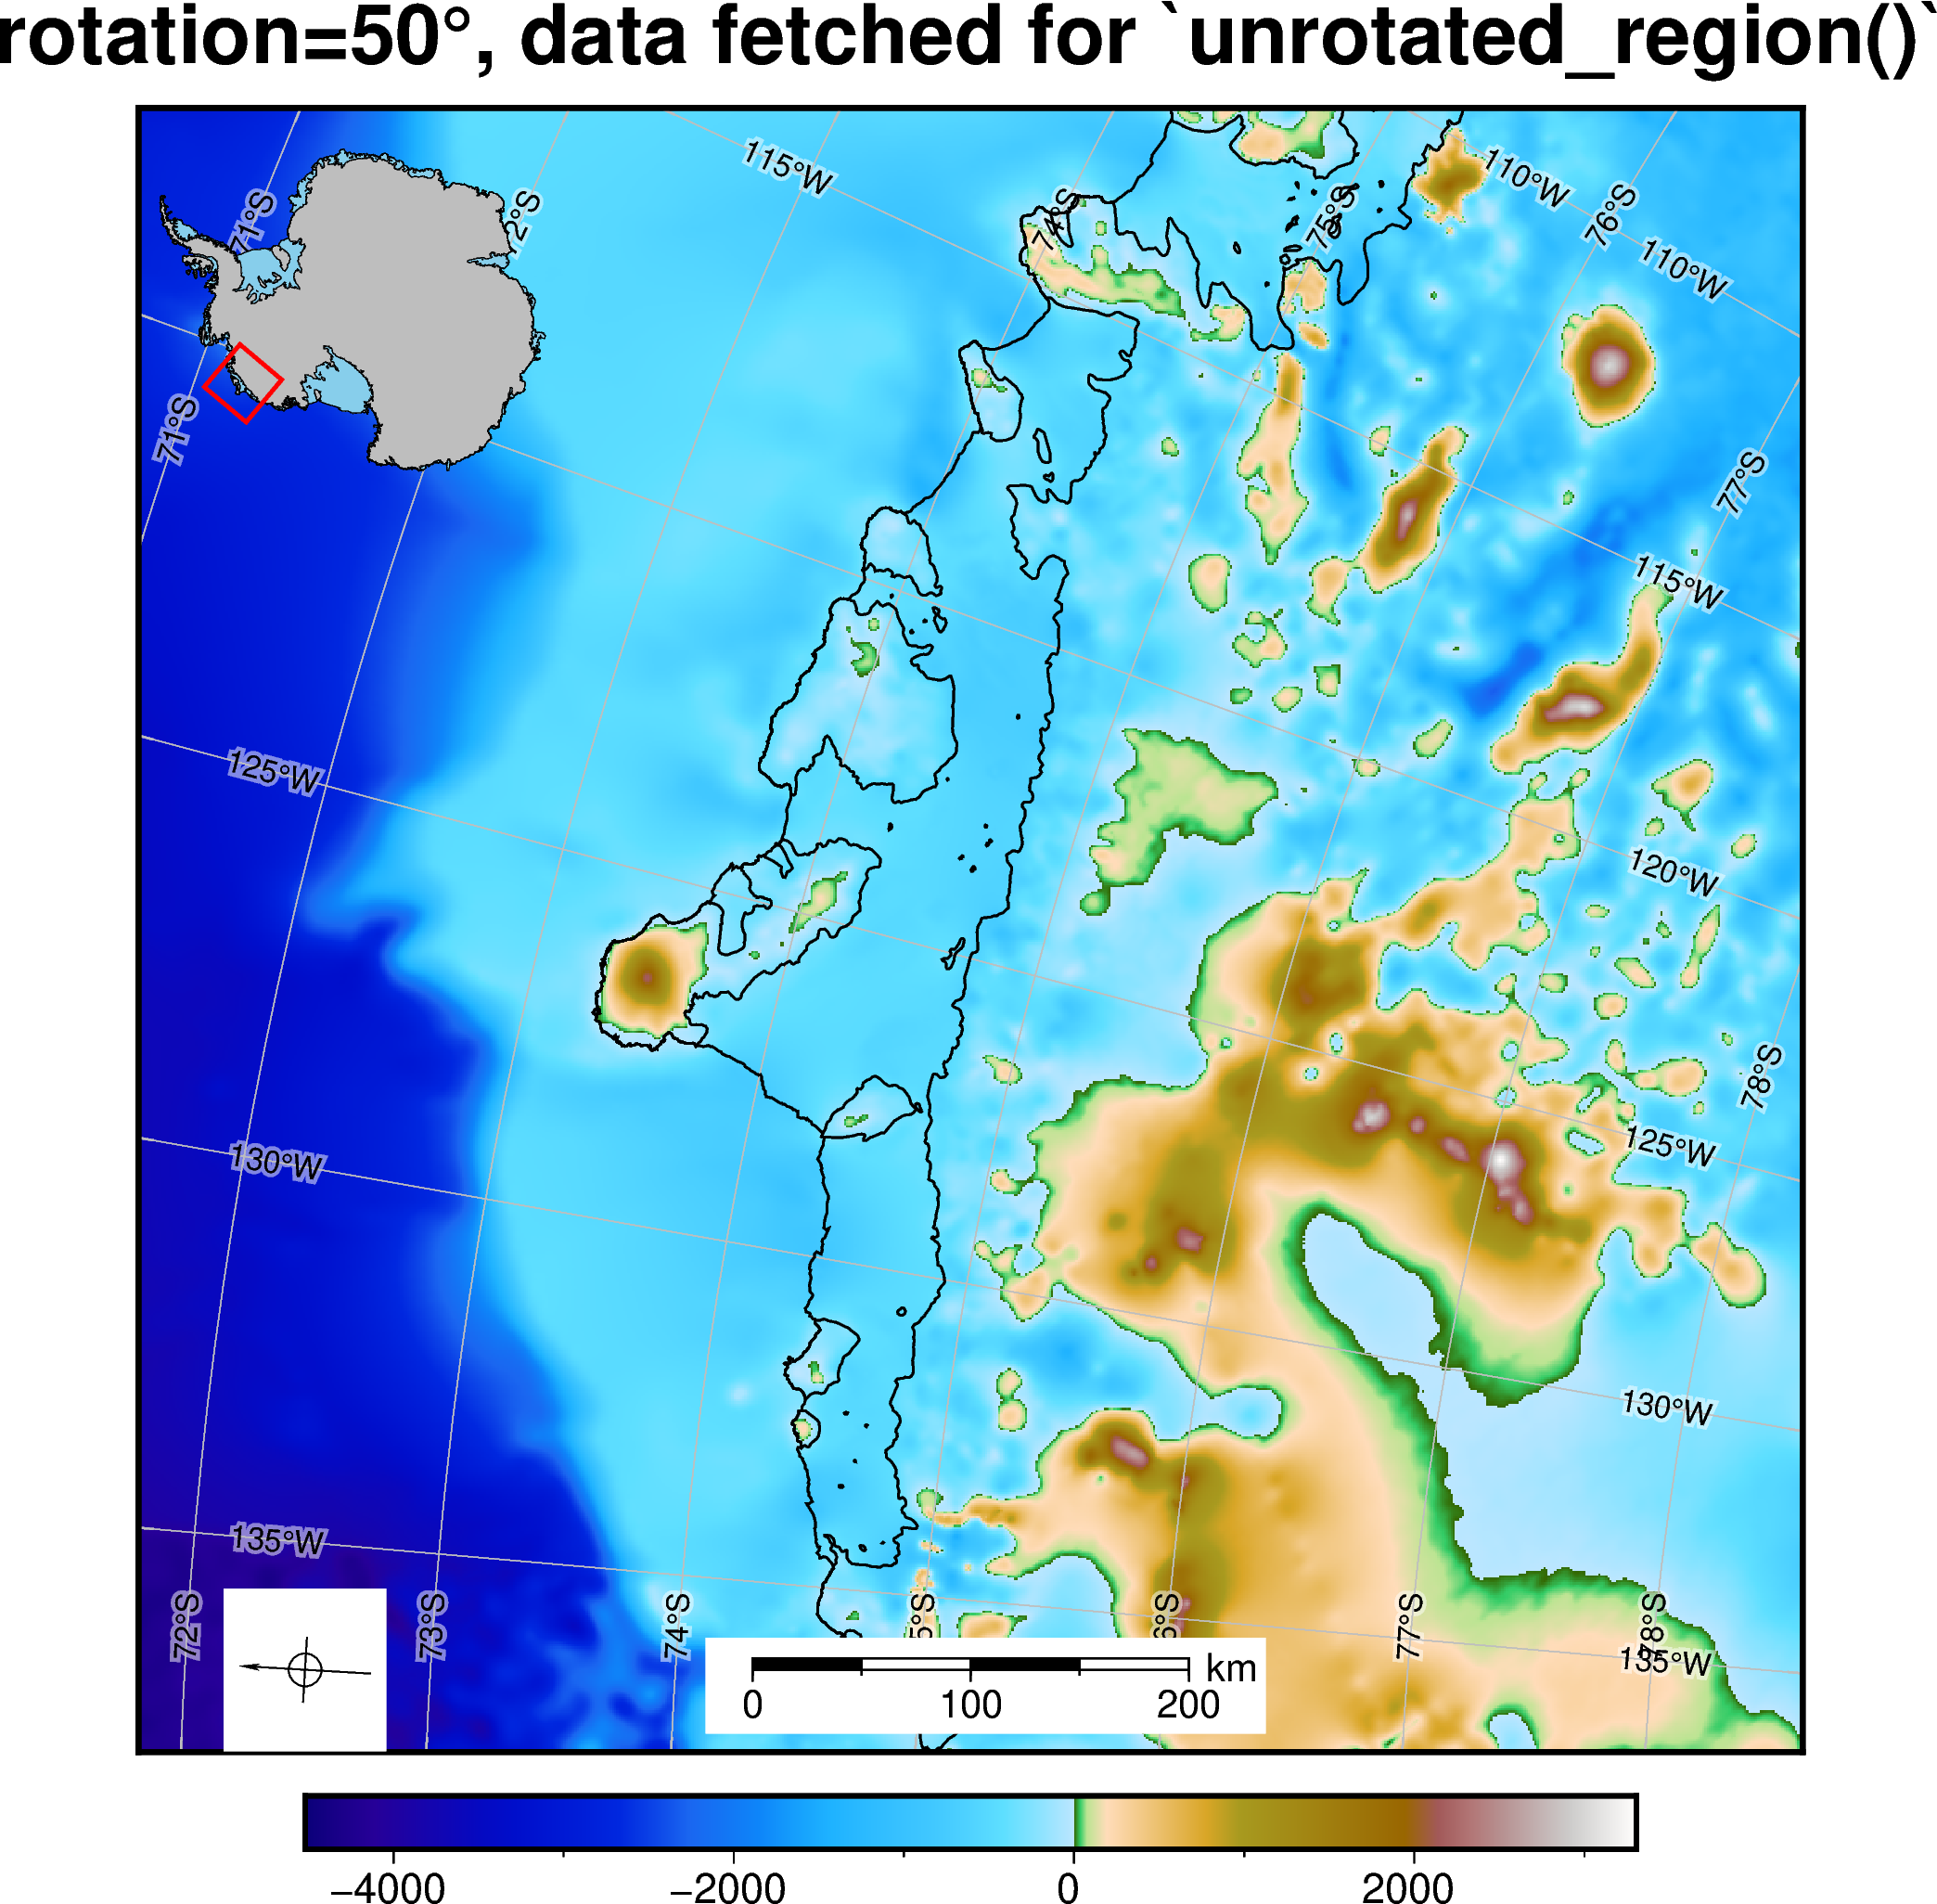

In [15]:
bigger_grid = ptk.fetch.bedmap2(layer="bed", region=needed)

fig = ptk.plot_grid(
    bigger_grid,
    region=region,
    cmap="etopo1",
    coast=True,
    gridlines=True,
    scalebar=True,
    inset=True,
    north_arrow=True,
    rose_box="+gwhite",
    rose_size="1.2c",
    rotation=50,
    title="rotation=50°, data fetched for `unrotated_region()`",
)
fig.show()

If you've already built the figure, the same value is available as `Figure.reg_base`,
so you don't need to recompute it.

If you *don't* pass a region: the map is zoomed to the bounding
box of your data, so a rotated map still shows the whole grid.

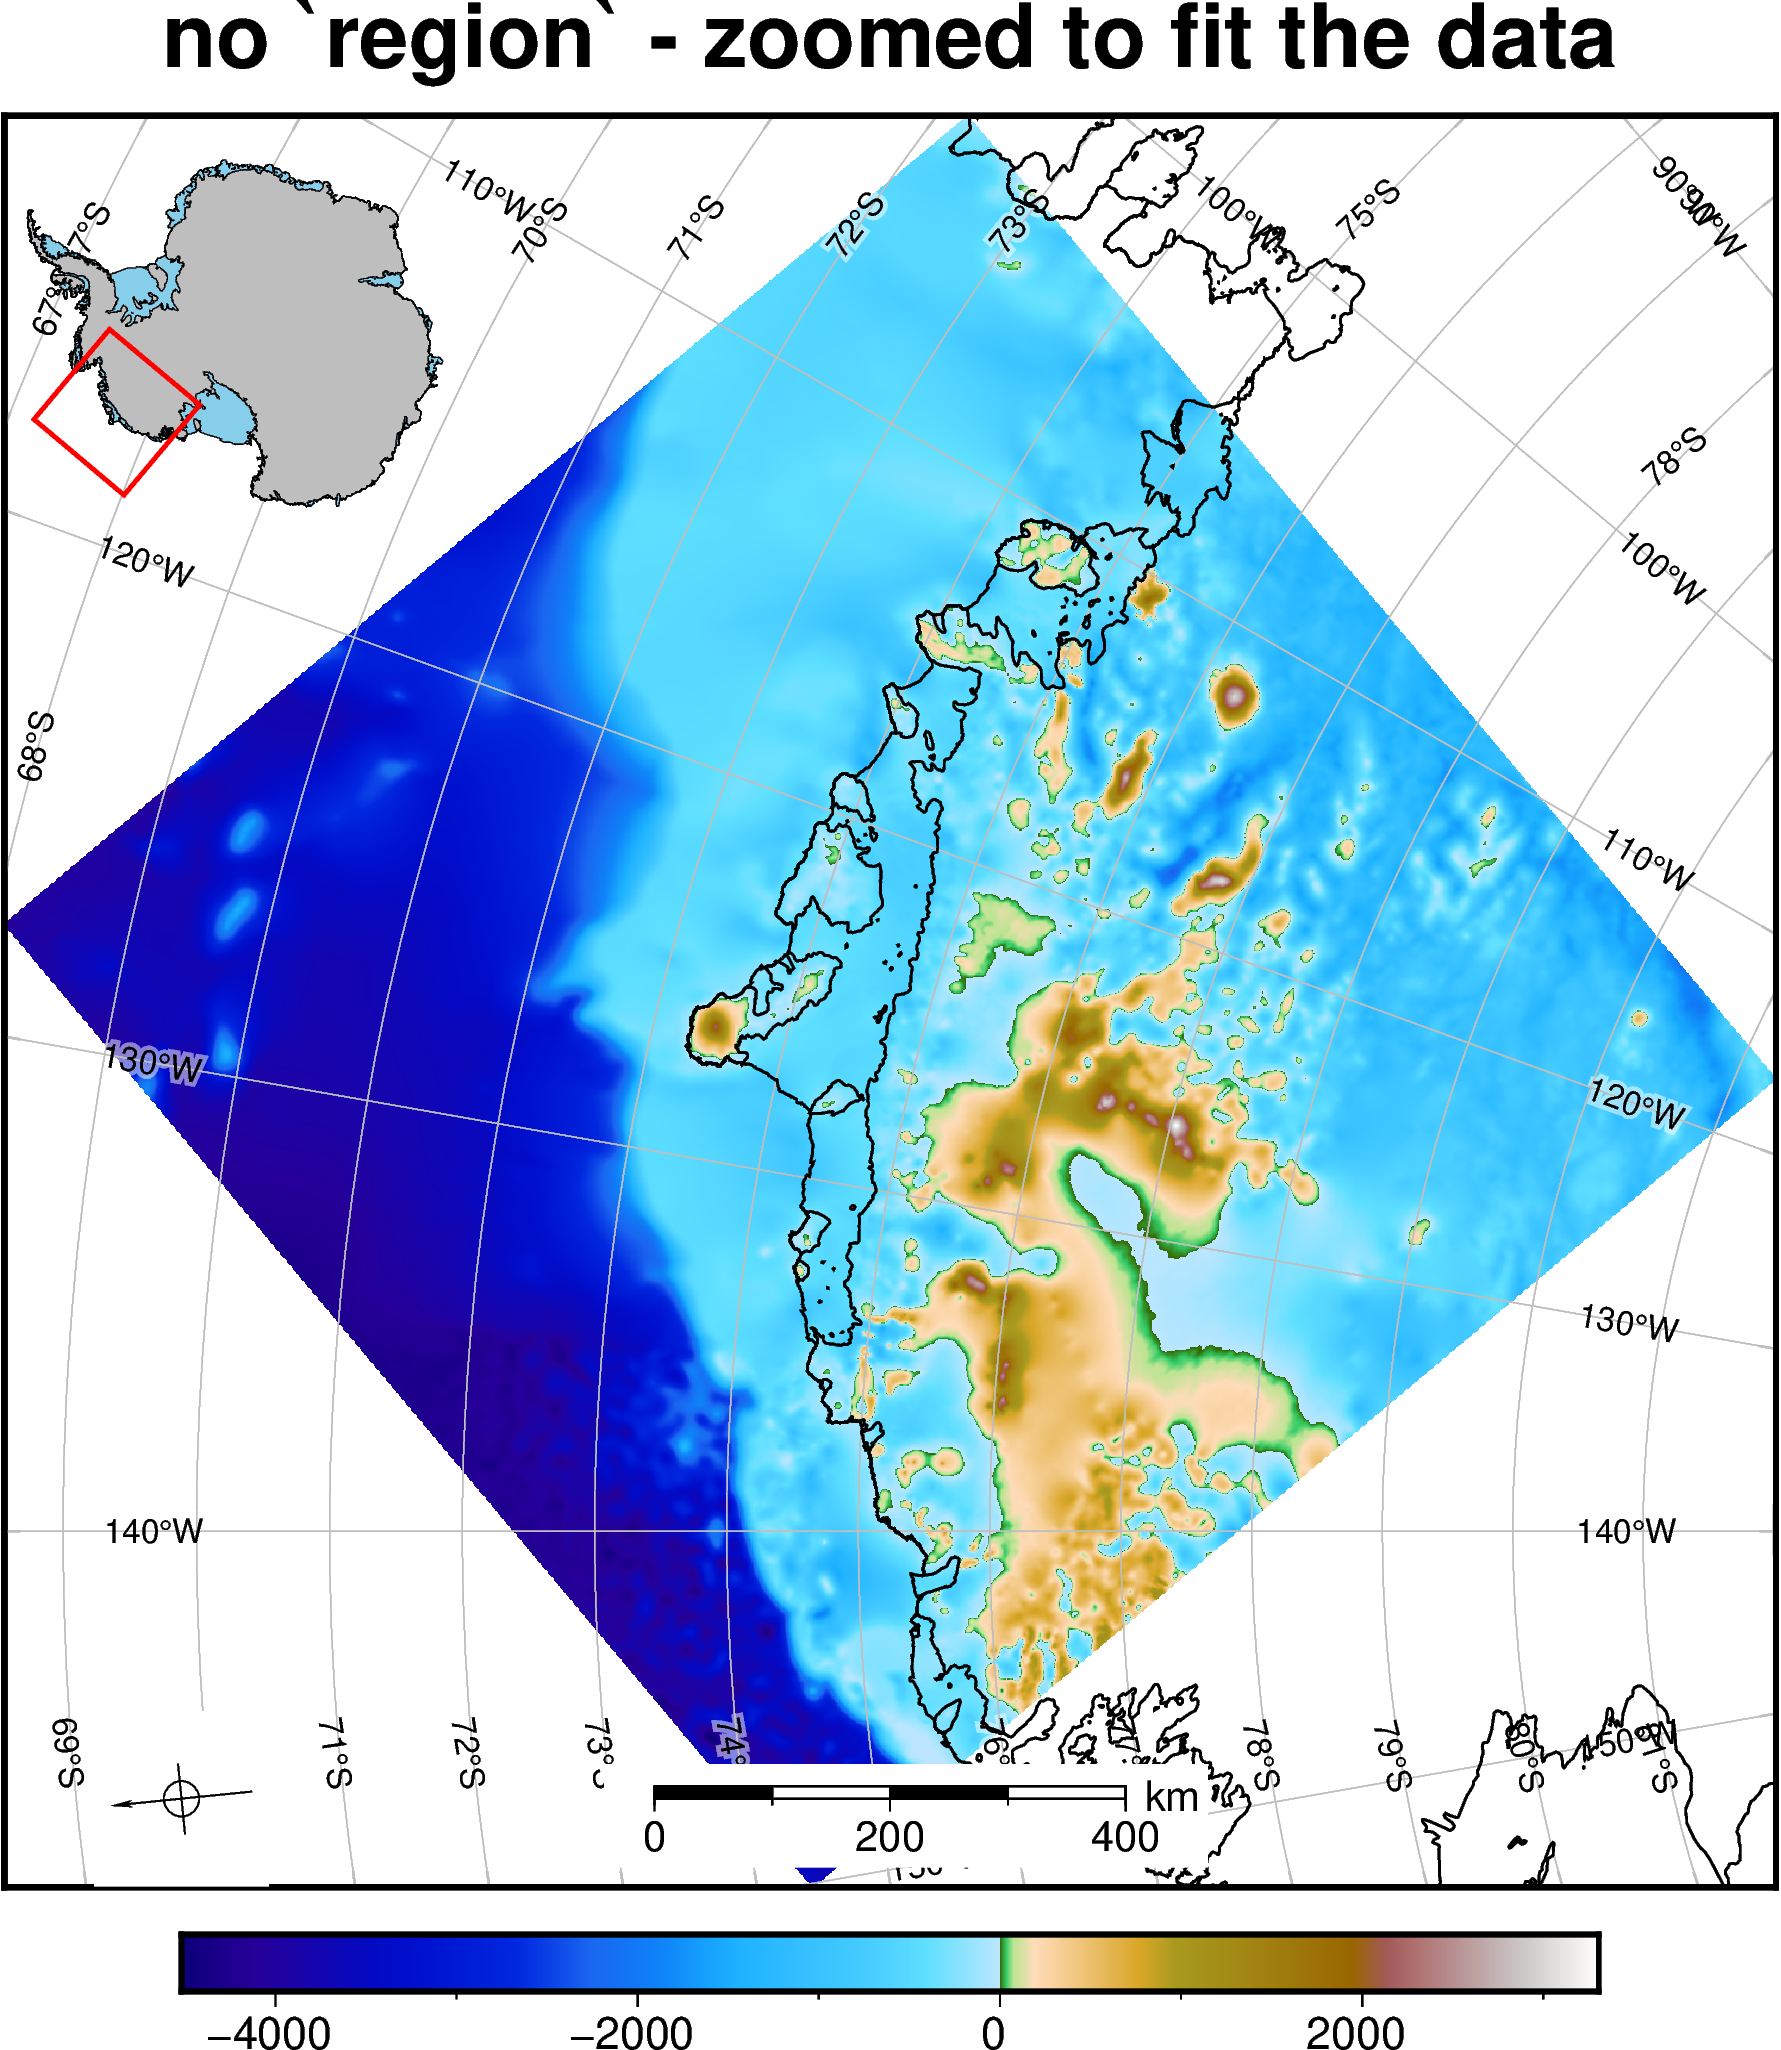

In [16]:
fig = ptk.plot_grid(
    bigger_grid,
    cmap="etopo1",
    coast=True,
    gridlines=True,
    scalebar=True,
    inset=True,
    north_arrow=True,
    rose_box="+gwhite",
    rose_size="1.2c",
    rotation=50,
    title="no `region` - zoomed to fit the data",
)
fig.show()

## Defining a rotated region using corners

Choosing the angle by eye, as above, means guessing twice: once at the rotation and
again at the region it applies to. Usually you already have something that *defines*
the orientation, the corners of the area you care about.

A plain `[xmin, xmax, ymin, ymax]` region can't express a tilted box, so instead you can
pass the corners themselves to `oriented_region()`. It finds the smallest **rotated**
rectangle enclosing them and returns everything the map needs:

| attribute | what it is |
|---|---|
| `.rotation` | the clockwise angle which squares the box up |
| `.easting`, `.northing` | the box's corners, in the unrotated projection |
| `.region` | the box in the rotated frame — what the map will show |
| `.data_region` | axis-aligned region covering the whole rotated map — fetch with this |

This is the rotated counterpart of `polygon_to_region()`, which throws the orientation
away by taking an axis-aligned bounding box.

### Where the corners come from

`oriented_region()` accepts anything it can pull easting/northing pairs out of, so the
corners can be typed in by hand, derived from a dataset, or clicked on a map. Only the
outer shape matters, you can pass four corners or a whole coastline, and the result is
the same box.

#### Manually

The simplest case is a list of `(easting, northing)` pairs in the projection's coordinates. A pair of coordinate arrays, or a dataframe with `easting`/`northing` (or
`x`/`y`) columns, work just as well.

These four points are a rough sketch of the corners of Getz, they don't have to make an exact rectangle, since `oriented_region()` fits the tightest box around whatever you give it.

In [17]:
data_df = pd.DataFrame(
    [
        (-1650e3, -750e3),
        (-1500e3, -680e3),
        (-1150e3, -1150e3),
        (-1250e3, -1250e3),
    ],
    columns=["easting", "northing"],
)
manual_box = ptk.oriented_region(data_df)

print(manual_box)

OrientedRegion(rotation=128.65980825409008, easting=array([-1250000.        , -1650000.        , -1524390.24384937,
       -1124390.24387619, -1250000.        ]), northing=array([-1250000.        ,  -750000.        ,  -649512.19515048,
       -1149512.19508786, -1250000.        ]), region=(-195217.20236076042, 445095.221382525, 1596095.8464597561, 1756954.8212468207), data_region=(-1650000.0, -1124390.243876185, -1250000.0, -649512.195150481))


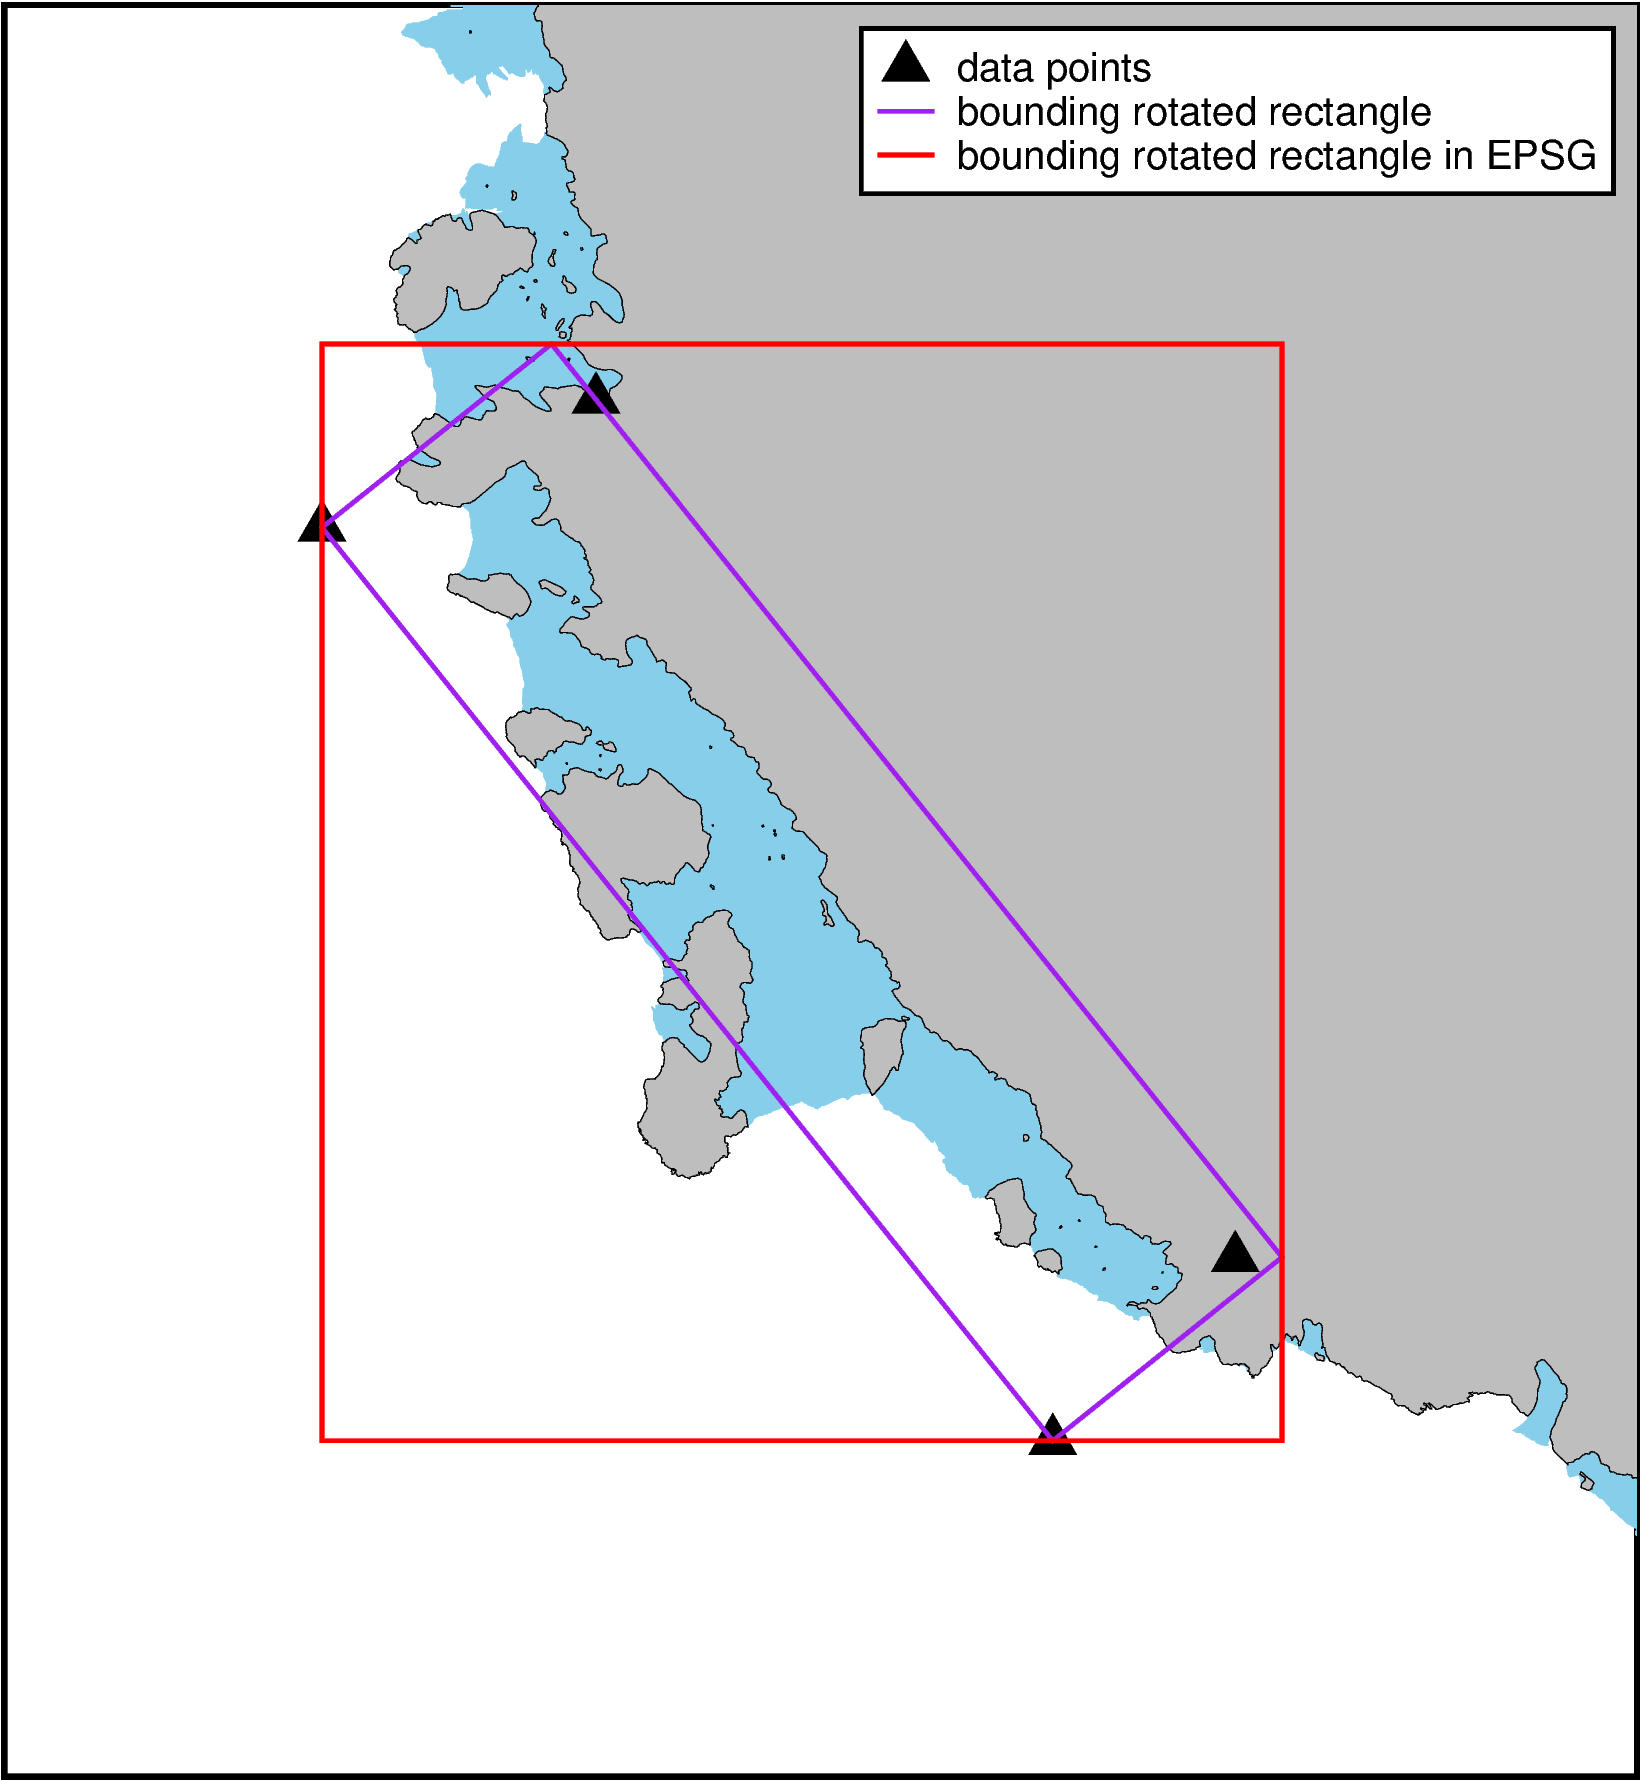

In [24]:
fig = ptk.basemap(
    simple_basemap=True,
    region=ptk.alter_region(ptk.regions.getz_ice_shelf, -200e3),
)
fig.add_points(
    data_df,
    style="t.4c",
    label="data points",
)
fig.plot(
    x=manual_box.easting,
    y=manual_box.northing,
    pen="1p,purple",
    label="bounding rotated rectangle",
)
fig.add_box(
    manual_box.data_region,
    pen="1p,red",
    label="bounding rotated rectangle in EPSG",
)
fig.legend()
fig.show()

#### From an interactive map

`regions.draw_region()` opens an interactive map you can draw on; the polygons you click come
back as lon/lat vertices, which `oriented_region()` converts for you. 

Any polygon works, not just a rectangle, trace roughly around the feature and the
fitted box will pick up its orientation.

In [22]:
vertices = ptk.regions.draw_region()   # click the corners of the feature on a map

Label(value='')

Map(center=[-90, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

In [26]:
df = ptk.shapes_to_df(vertices)

In [31]:
box = ptk.oriented_region(df, pad=50e3)
print(box)

OrientedRegion(rotation=113.19856528293016, easting=array([-1290730.37508144, -1470912.23536314, -1685165.95144069,
       -1504984.091159  , -1290730.37508144]), northing=array([-1116659.35419167, -1193880.05753703,  -693954.11199796,
        -616733.40865261, -1116659.35419167]), region=(-517929.00775199884, 25974.114022615435, 1626241.8508299051, 1822273.837504842), data_region=(-1685165.9514406899, -1290730.3750814437, -1193880.057537031, -616733.4086526069))


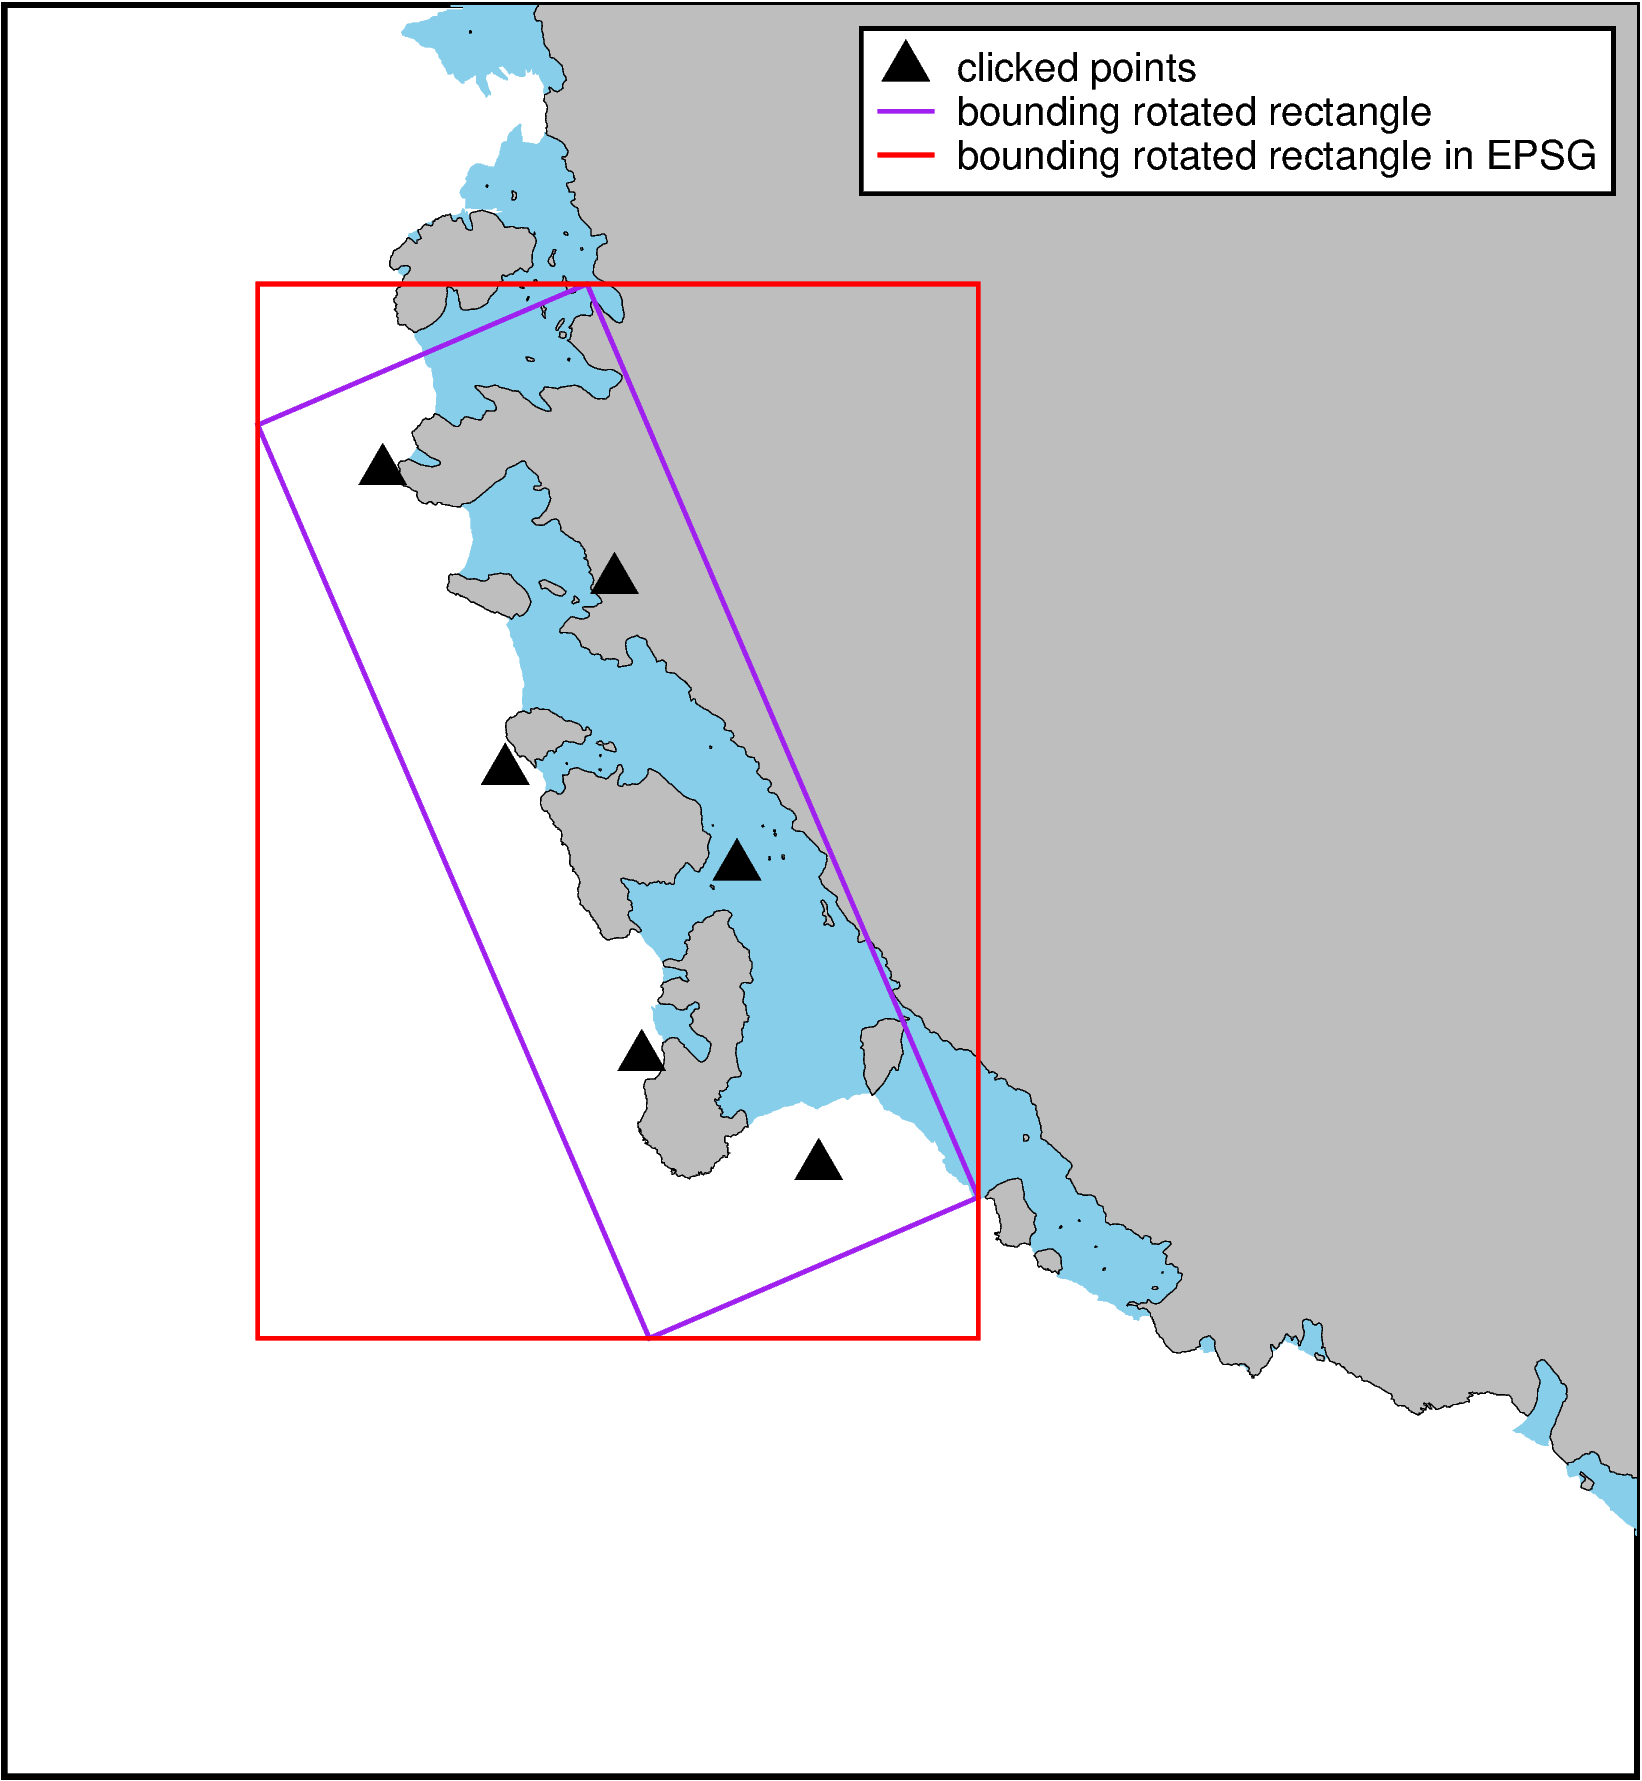

In [29]:
fig = ptk.basemap(
    simple_basemap=True,
    region=ptk.alter_region(ptk.regions.getz_ice_shelf, -200e3),
)
fig.add_points(
    df,
    style="t.4c",
    label="clicked points",
)
fig.plot(
    x=box.easting,
    y=box.northing,
    pen="1p,purple",
    label="bounding rotated rectangle",
)
fig.add_box(
    box.data_region,
    pen="1p,red",
    label="bounding rotated rectangle in EPSG",
)
fig.legend()
fig.show()

#### From a shapefile or a dataset

More often the feature has already been mapped, so let the outline choose the angle for
you. Pass a `geopandas.GeoDataFrame`, or just the path to the file — and every vertex
is used, so the box is fitted to the true shape rather than to four guessed points.

The box is the *smallest* one enclosing the data, which is usually tighter than you
want for a figure, so `pad` zooms out by a given number of metres on each side. Because
padding happens in the rotated frame it stays square to the box; a tuple pads the two
axes separately, and negative values zoom back in.

In [33]:
import geopandas as gpd

shelves = gpd.read_file(
    ptk.fetch.antarctic_boundaries(version="IceShelf"), engine="pyogrio"
)
getz_outline = shelves[shelves["NAME"].str.contains("Getz", case=False, na=False)]

# zoom out 50 km from the outline so the shelf isn't jammed against the frame
box = ptk.oriented_region(getz_outline, pad=50e3)
print(box)

OrientedRegion(rotation=129.55696708966366, easting=array([-1099645.7279003 , -1289190.43782268, -1723971.02546721,
       -1534426.31554483, -1099645.7279003 ]), northing=array([-1166725.40130078, -1323290.7820228 ,  -796926.9078067 ,
        -640361.52708468, -1166725.40130078]), region=(-199231.68794645896, 483478.4170558774, 1590841.1685167884, 1836686.4765871014), data_region=(-1723971.025467207, -1099645.7279003046, -1323290.7820228005, -640361.5270846823))


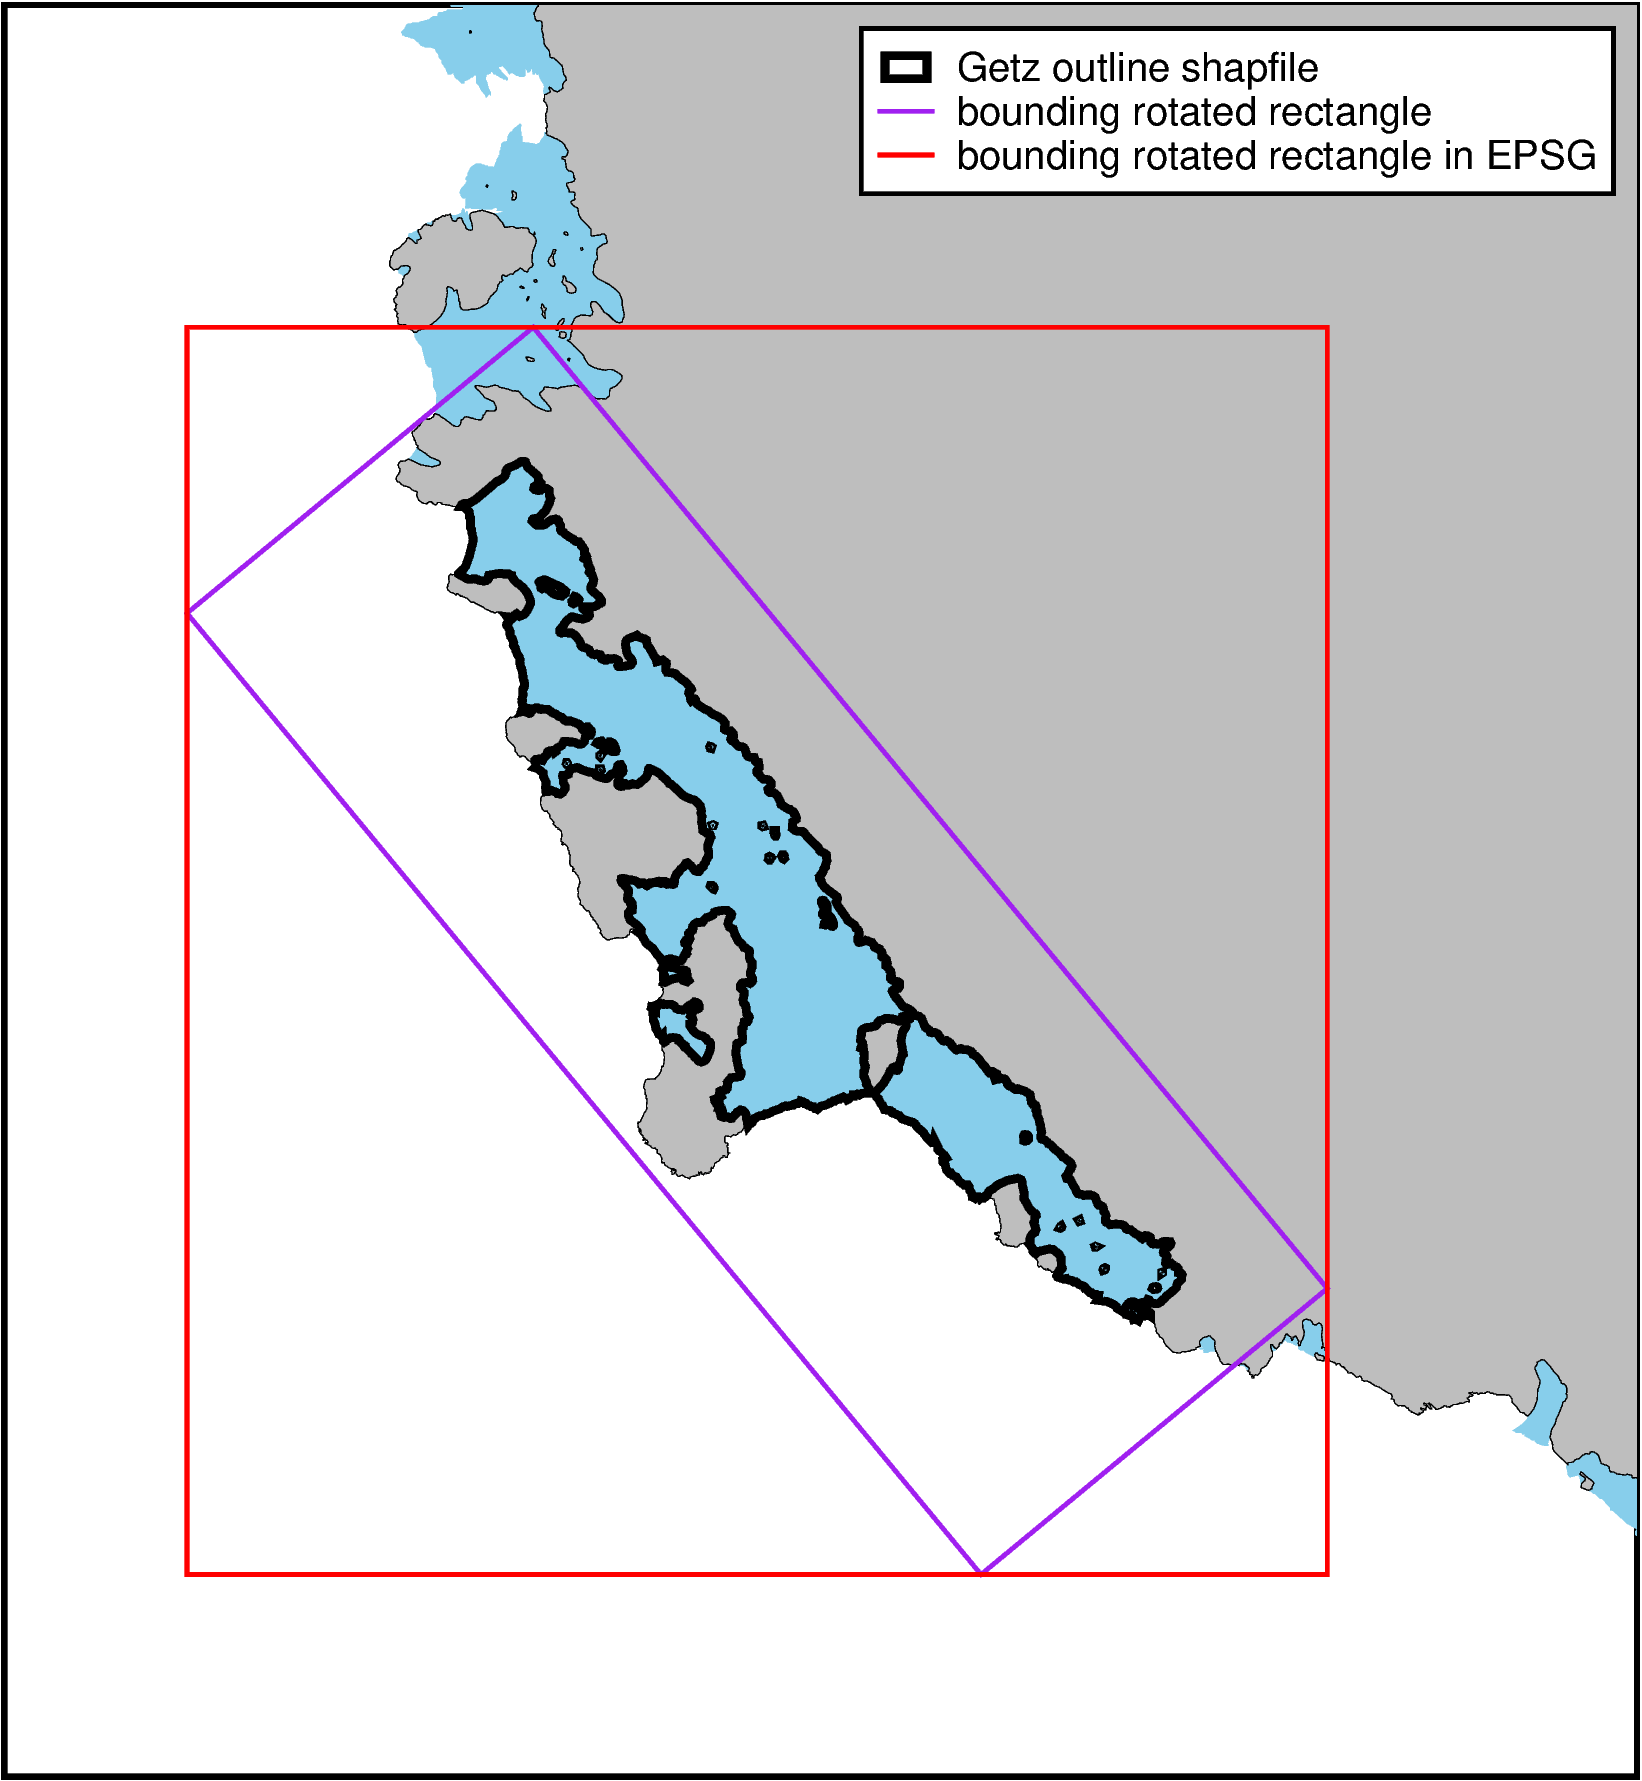

In [36]:
fig = ptk.basemap(
    simple_basemap=True,
    region=ptk.alter_region(ptk.regions.getz_ice_shelf, -200e3),
)
fig.plot(
    getz_outline,
    pen="2p,black",
    label="Getz outline shapfile",
)
fig.plot(
    x=box.easting,
    y=box.northing,
    pen="1p,purple",
    label="bounding rotated rectangle",
)
fig.add_box(
    box.data_region,
    pen="1p,red",
    label="bounding rotated rectangle in EPSG",
)
fig.legend()
fig.show()

The oriented box is much the tighter of the two, which is the whole point: the
axis-aligned box has to be wide enough *and* tall enough to hold a diagonal feature, so
most of it is empty ocean and ice sheet.

Note also how close the fitted angle is to the one from the four hand-picked corners
above, a rough sketch is usually enough to get the orientation right.

The angle itself is larger than you might expect, because four quarter turns square the
box up equally well and `oriented_region()` picks the one which lays the long axis
across the page with true north nearest the top. Getz is a long way round from the
projection's own top meridian, where north already points down the page, so a big turn
is needed to bring it back up. Add 90 or 180 to `box.rotation` if you'd rather have one
of the other three; a half turn is free, since the box still fits the same
`data_region`.

### Fetching and plotting the rotated map

The two regions on the box are there for the map's two halves. Fetch your data with
`.data_region`, which is axis-aligned and in the unrotated projection, so it reaches
into every corner of the tilted footprint. Then pass the box itself as `region` — the
rotation comes along with it, so you don't pass `rotation` at all.

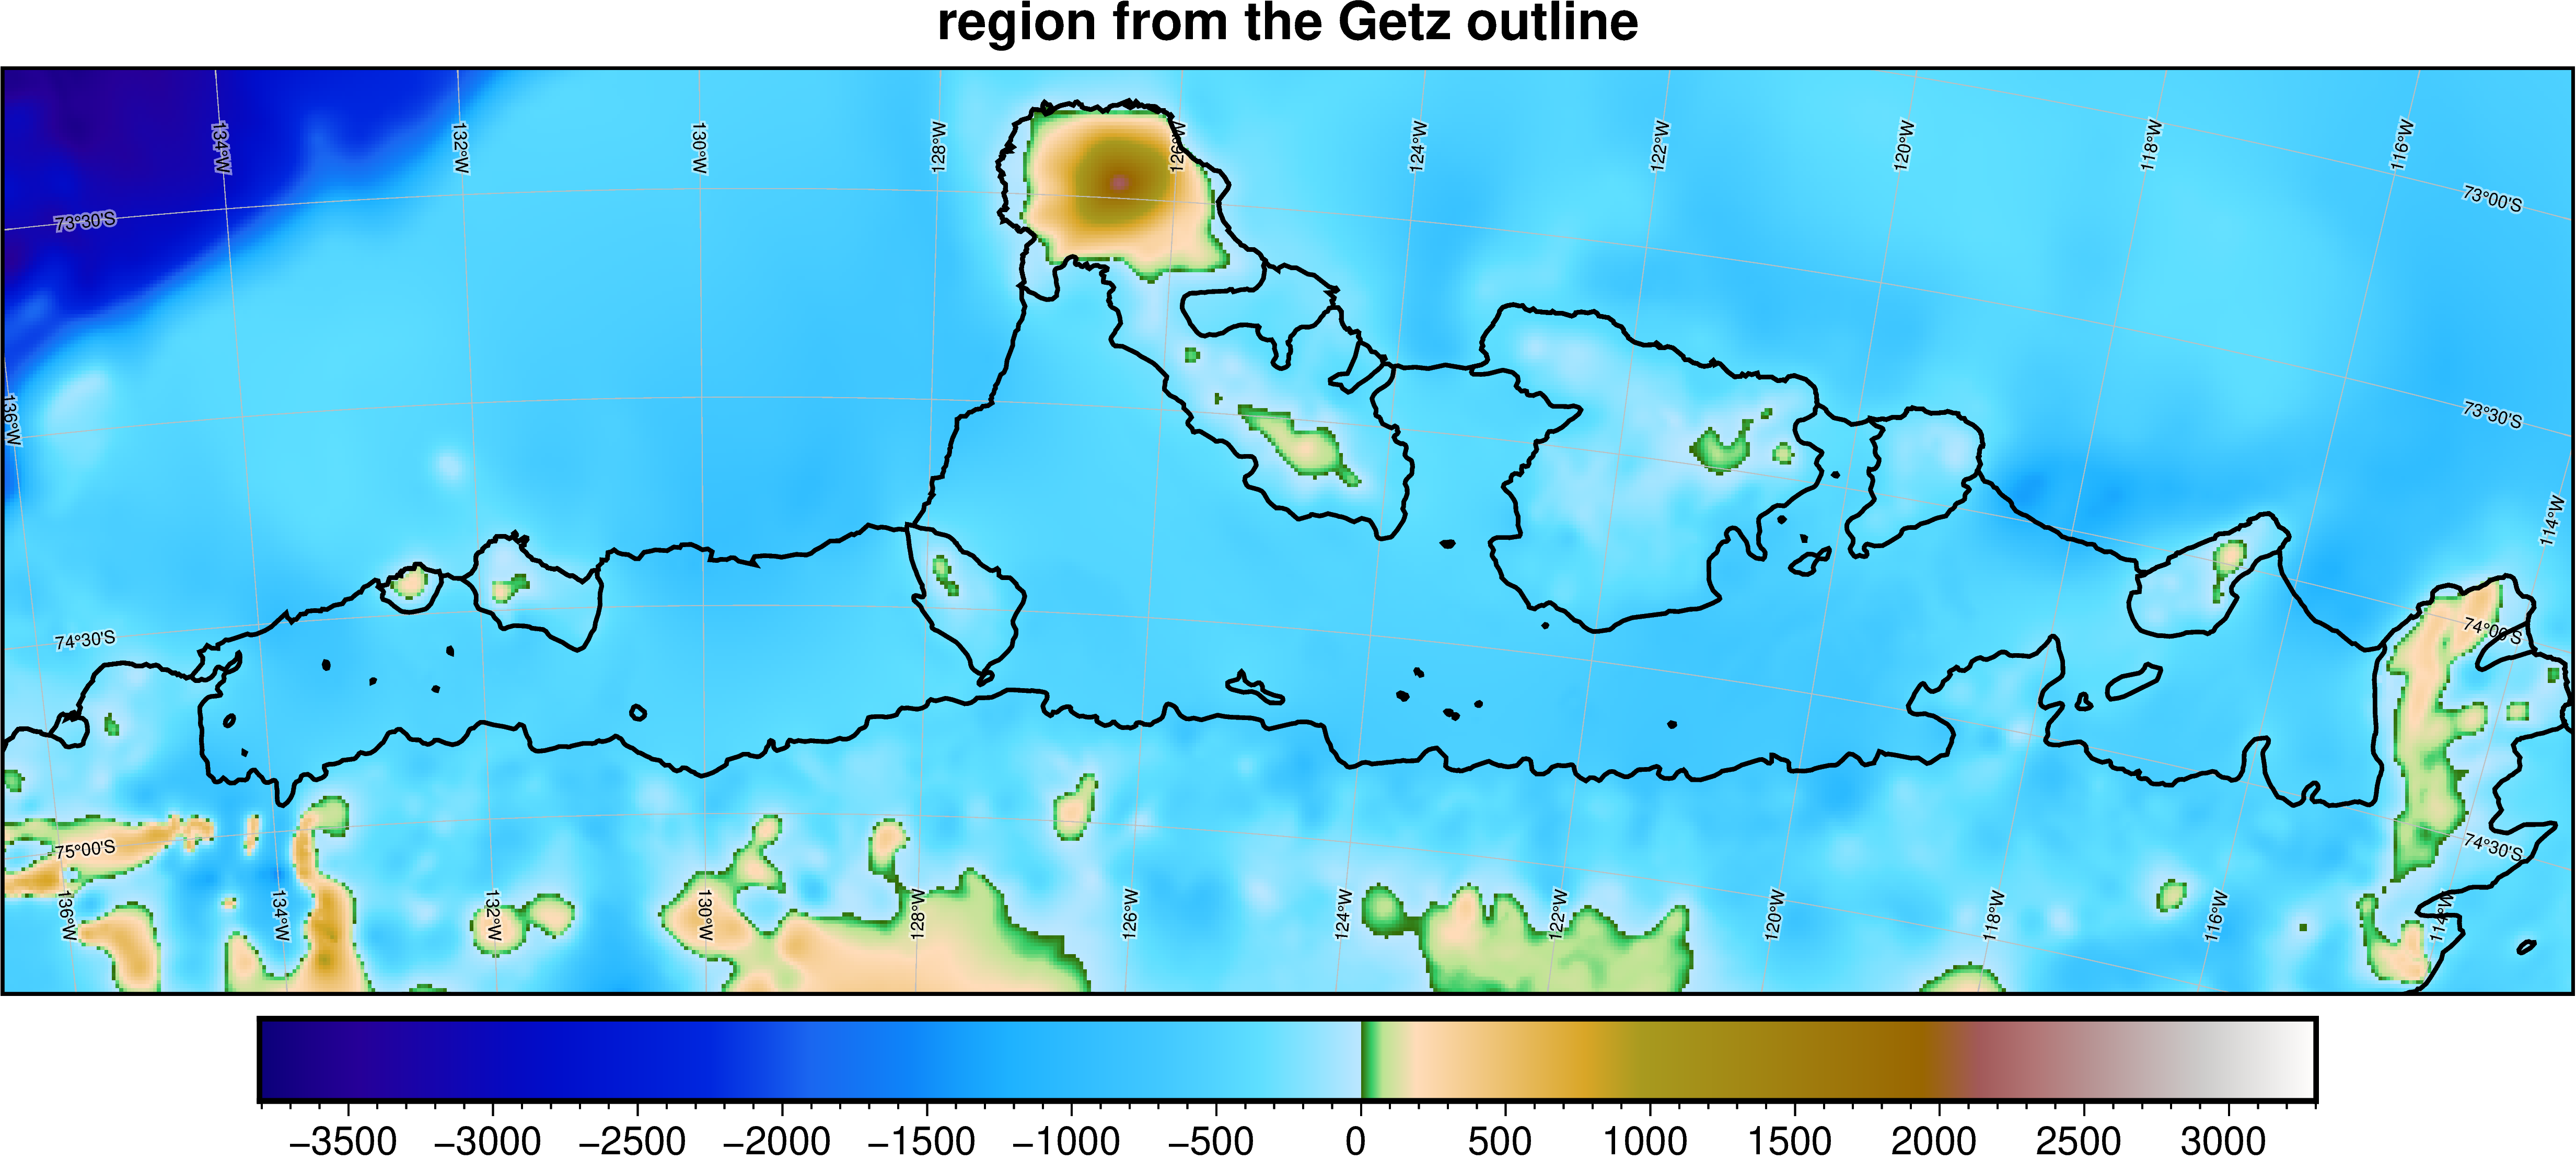

In [39]:
outline_grid = ptk.fetch.bedmap2(layer="bed", region=box.data_region)

fig = ptk.plot_grid(
    outline_grid,
    region=box,
    cmap="etopo1",
    coast=True,
    coast_pen='2p',
    gridlines=True,
    title="region from the Getz outline",
)
fig.show()

The box works anywhere a region does, so `basemap()` and the `Figure` class take it the
same way, as does every other map element.